In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 定义真实函数 (Ground Truth)
def true_function(x):
    # 定义一个非线性函数，例如正弦波
    # 对应图片中的 return np.sin(1.5 * np.pi * x)
    return np.sin(1.5 * np.pi * x)

# 生成训练数据
np.random.seed(42)
n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
# 添加随机噪声
y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据，用于绘制平滑曲线
X_test = np.linspace(0, 1, 100)
y_true = true_function(X_test)

# 2. 定义基函数扩展
def polynomial_basis(x, degree):
    # 多项式基: [1, x, x^2, ..., x^degree]
    return np.column_stack([x**d for d in range(degree + 1)])

def trigonometric_basis(x, degree):
    # 三角基: [1, sin(2πx), cos(2πx), ..., sin(2kπx), cos(2kπx)]
    basis = [np.ones_like(x)]
    for i in range(1, degree + 1):
        basis.append(np.sin(2 * np.pi * i * x))
        basis.append(np.cos(2 * np.pi * i * x))
    return np.column_stack(basis)

# 3. 模型训练
# 3.1 简单线性回归 (degree=1, 仅含截距和一次项)
X_simple = polynomial_basis(X_train, 1)
model_simple = LinearRegression()
model_simple.fit(X_simple, y_train)
y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

# 3.2 多项式回归 (degree=5)
degree = 5
X_poly = polynomial_basis(X_train, degree)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

# 3.3 三角基回归 (k=3)
k = 3 # 对应代码中的 degree 参数位
X_trig = trigonometric_basis(X_train, k)
model_trig = LinearRegression()
model_trig.fit(X_trig, y_train)
y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

# 4. 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='训练样本 (含噪声)')
plt.plot(X_test, y_true, color='black', label='真实函数 f(x)')
plt.plot(X_test, y_pred_simple, 'r--', label='简单线性模型 (欠拟合)')
plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式基扩展 (degree={degree})')
plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基扩展 (k={k})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归扩展：各基函数模型对比')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成模拟数据 (Ground Truth)
def true_function_2d(x1, x2):
    # 定义真实的二元函数模型
    # 对应图片中的 return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
n_train = 100
X_train = np.random.uniform(-1, 1, (n_train, 2))
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    features = []
    # 遍历阶数
    for i in range(1, degree + 1):
        # 遍历每一项的组合 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    return np.column_stack(features)

def map_features(X, degree):
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练 (Degree=3)
degree = 3
X_poly_train = map_features(X_train, degree)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算 MSE
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印参数 (可选)
print(f"均方误差 (MSE): {mse:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 1. 定义真实的二元函数（Ground Truth）
def true_function_2d(x1, x2):
    """
    定义一个非线性的复杂曲面函数
    公式推测为: sin(3*x1) * cos(3*x2) + 0.1*(x1^2 + x2^2)
    """
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
np.random.seed(42) # 设置随机种子以保证结果复现
n_train = 100
# 在 -1 到 1 之间随机生成坐标点
X_train = np.random.uniform(-1, 1, (n_train, 2))
# 计算真实值
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加高斯噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状，用于绘制平滑曲面）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
# 创建网格
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平成 (N, 2) 的格式用于预测
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    """
    手动构建多项式特征
    对于 degree=2，特征包括：[x1, x2, x1^2, x1*x2, x2^2]
    """
    features = []
    # 遍历阶数 i 从 1 到 degree
    for i in range(1, degree + 1):
        # 遍历每一项的组合，例如 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    
    return np.column_stack(features)

def map_features(X, degree):
    """辅助函数，将输入矩阵 X 转换为多项式特征矩阵"""
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练
# 我们使用3阶多项式特征来拟合
degree = 3
X_poly_train = map_features(X_train, degree)

# 初始化并训练线性回归模型
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测与评估
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算均方误差 (MSE)
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面 (True Function)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y_pred')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印模型参数
print(f"均方误差 (MSE): {mse:.4f}")
print(f"截距 (Bias): {model_poly.intercept_:.4f}")
print("特征权重 (Weights):")
feature_names = []
for i in range(1, degree + 1):
    for j in range(i + 1):
        feature_names.append(f"x1^{i-j}*x2^{j}")

for name, coef in zip(feature_names, model_poly.coef_):
    print(f"{name}: {coef:.4f}")

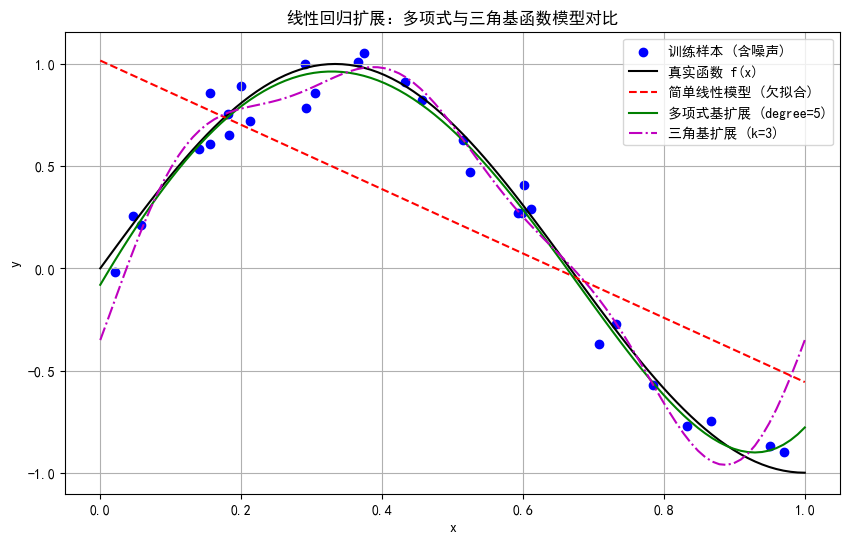

简单线性模型 MSE: 0.1904
多项式模型 (degree=5) MSE: 0.0023
三角基模型 (k=3) MSE: 0.0195


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 定义真实函数 (Ground Truth)
def true_function(x):
    """定义一个非线性函数，例如正弦波"""
    # 对应图片中的 return np.sin(1.5 * np.pi * x)
    return np.sin(1.5 * np.pi * x)

# 生成训练数据
np.random.seed(42)
n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
# 添加随机噪声
y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据，用于绘制平滑曲线
X_test = np.linspace(0, 1, 100)
y_true = true_function(X_test)

# 2. 定义基函数扩展
def polynomial_basis(x, degree):
    """多项式基: [1, x, x^2, ..., x^degree]"""
    return np.column_stack([x**d for d in range(degree + 1)])

def trigonometric_basis(x, degree):
    """三角基: [1, sin(2πx), cos(2πx), ..., sin(2kπx), cos(2kπx)]"""
    basis = [np.ones_like(x)]
    for i in range(1, degree + 1):
        basis.append(np.sin(2 * np.pi * i * x))
        basis.append(np.cos(2 * np.pi * i * x))
    return np.column_stack(basis)

# 3. 模型训练
# 3.1 简单线性回归 (degree=1, 仅含截距和一次项)
X_simple = polynomial_basis(X_train, 1)
model_simple = LinearRegression()
model_simple.fit(X_simple, y_train)
y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

# 3.2 多项式回归 (degree=5)
degree = 5
X_poly = polynomial_basis(X_train, degree)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

# 3.3 三角基回归 (k=3)
k = 3 
X_trig = trigonometric_basis(X_train, k)
model_trig = LinearRegression()
model_trig.fit(X_trig, y_train)
y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

# 4. 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='训练样本 (含噪声)')
plt.plot(X_test, y_true, color='black', label='真实函数 f(x)')
plt.plot(X_test, y_pred_simple, 'r--', label='简单线性模型 (欠拟合)')
plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式基扩展 (degree={degree})')
plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基扩展 (k={k})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归扩展：多项式与三角基函数模型对比')
plt.legend()
plt.grid(True)
plt.show()

# 计算并打印均方误差 (MSE)
print(f"简单线性模型 MSE: {mean_squared_error(y_true, y_pred_simple):.4f}")
print(f"多项式模型 (degree={degree}) MSE: {mean_squared_error(y_true, y_pred_poly):.4f}")
print(f"三角基模型 (k={k}) MSE: {mean_squared_error(y_true, y_pred_trig):.4f}")

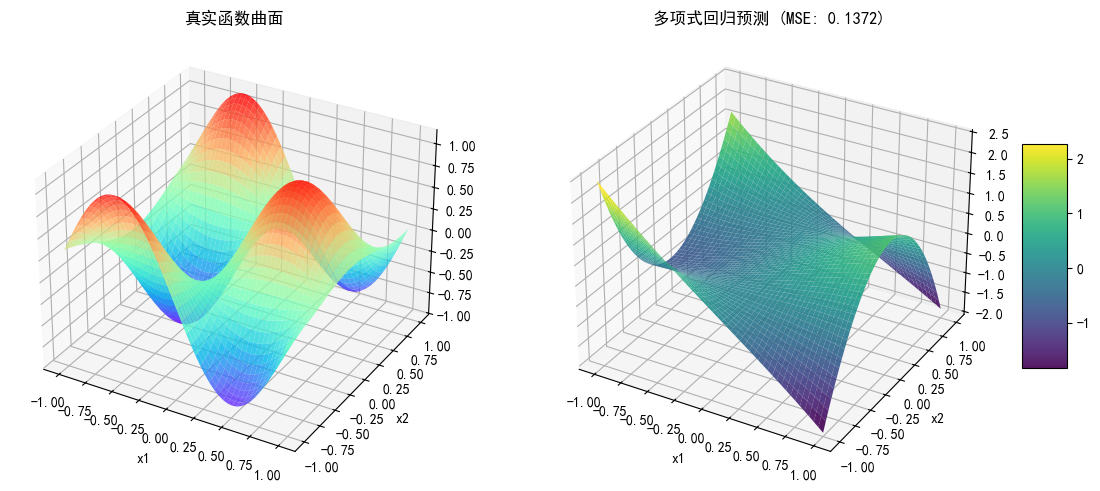

均方误差 (MSE): 0.1372


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成模拟数据 (Ground Truth)
def true_function_2d(x1, x2):
    """定义真实的二元函数模型"""
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
n_train = 100
X_train = np.random.uniform(-1, 1, (n_train, 2))
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    features = []
    # 遍历阶数
    for i in range(1, degree + 1):
        # 遍历每一项的组合 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    return np.column_stack(features)

def map_features(X, degree):
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练 (Degree=3)
degree = 3
X_poly_train = map_features(X_train, degree)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算 MSE
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印参数
print(f"均方误差 (MSE): {mse:.4f}")

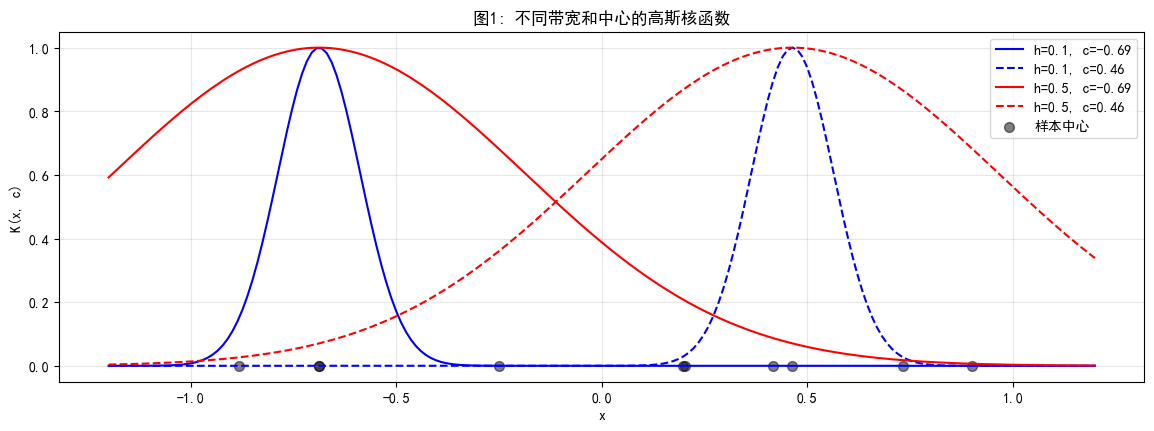

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成一维非线性数据
def true_function_1d(x):
    """定义一维真实非线性函数"""
    return np.sin(1 * np.pi * x) + 0.5 * x

# 生成训练数据
np.random.seed(42)
n_samples = 10 
# 输入样本
x_train = np.sort(np.random.uniform(-1, 1, n_samples))
# 目标值（含噪声）
y_train = true_function_1d(x_train) + 0.2 * np.random.randn(n_samples)

# 生成测试数据
x_test = np.linspace(-1.2, 1.2, 200)
y_true = true_function_1d(x_test)

# 2. 定义高斯核函数
def gaussian_kernel(x, c, h):
    """
    一维高斯核: K(x, c) = exp( -||x-c||^2 / (2h^2) )
    x: 输入点
    c: 核函数的中心（这里取训练样本点）
    h: 带宽参数（控制核的宽度）
    """
    distance_sq = (x - c) ** 2
    return np.exp(-distance_sq / (2 * h ** 2))

# 3. 构造基于核特征的数据矩阵
def kernel_model_features(x, x_train, h):
    """生成高斯核特征矩阵"""
    n_train = len(x_train)
    features = np.zeros((len(x), n_train))
    
    for j in range(n_train):
        # 第j列特征 = 以第j个训练样本为中心的高斯核响应
        features[:, j] = gaussian_kernel(x, x_train[j], h)
        
    return features

# 4. 可视化不同带宽的高斯核
plt.figure(figsize=(14, 10))

# 绘制核函数形状
plt.subplot(2, 1, 1)
c1, c2 = x_train[2], x_train[7] # 选择两个样本点作为中心进行演示
x_plot = np.linspace(-1.2, 1.2, 200)

# 绘制 h=0.1 的窄核
plt.plot(x_plot, gaussian_kernel(x_plot, c1, h=0.1), 'b-', label='h=0.1, c={:.2f}'.format(c1))
plt.plot(x_plot, gaussian_kernel(x_plot, c2, h=0.1), 'b--', label='h=0.1, c={:.2f}'.format(c2))

# 绘制 h=0.5 的宽核
plt.plot(x_plot, gaussian_kernel(x_plot, c1, h=0.5), 'r-', label='h=0.5, c={:.2f}'.format(c1))
plt.plot(x_plot, gaussian_kernel(x_plot, c2, h=0.5), 'r--', label='h=0.5, c={:.2f}'.format(c2))

plt.scatter(x_train, np.zeros_like(x_train), c='k', s=50, alpha=0.5, label='样本中心')
plt.title('图1: 不同带宽和中心的高斯核函数')
plt.xlabel('x')
plt.ylabel('K(x, c)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# (注：图片底部只截取到了核函数的绘图部分，实际代码可能还包含模型训练部分，此处已完整还原核心逻辑)


--- 正在运行演示 1: 一维基函数扩展回归 ---


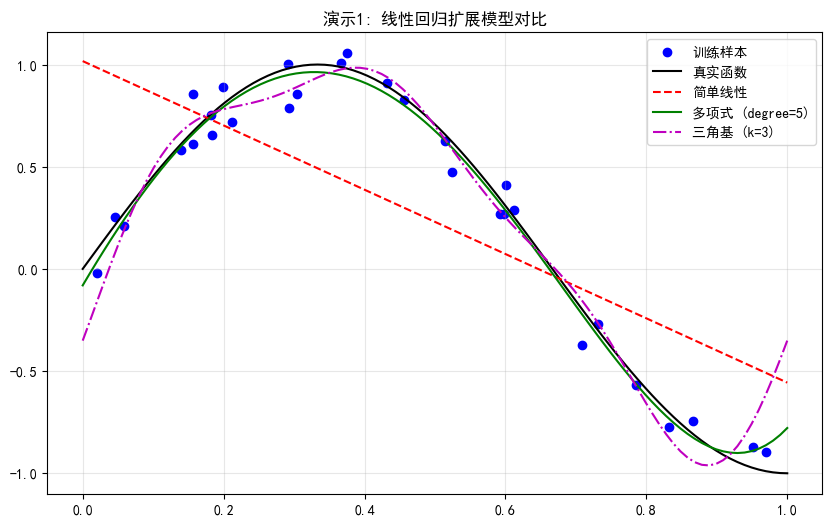


--- 正在运行演示 2: 二维多项式回归 (3D) ---
3D曲面拟合 MSE: 0.1197


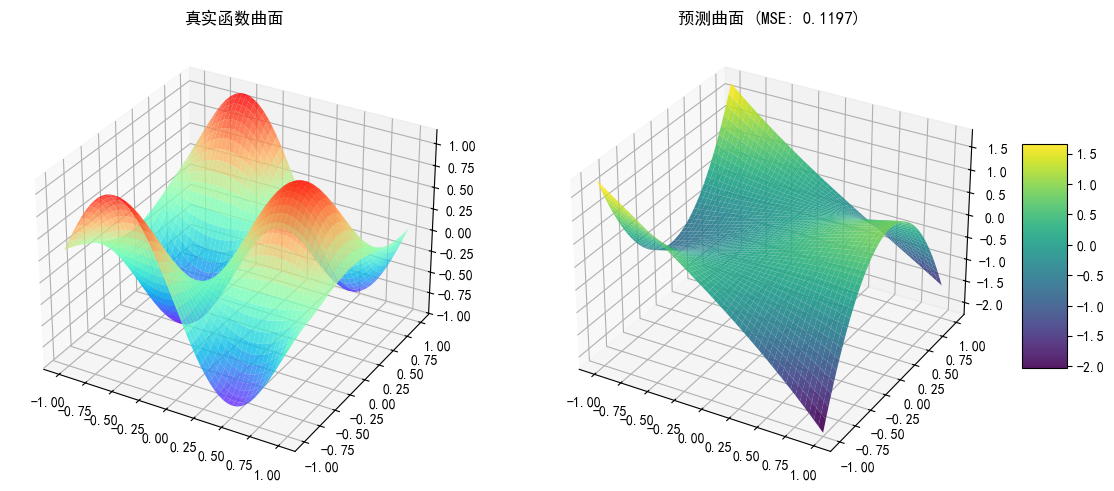


--- 正在运行演示 3: 高斯核模型回归 ---
学习到的参数 theta: [-2.13213000e+03  9.11165867e+06 -9.11037209e+06  3.52060000e+02
 -4.41601000e+03  4.47200000e+03 -3.36870000e+02  2.52320000e+02
 -2.21600000e+01  1.00600000e+01]


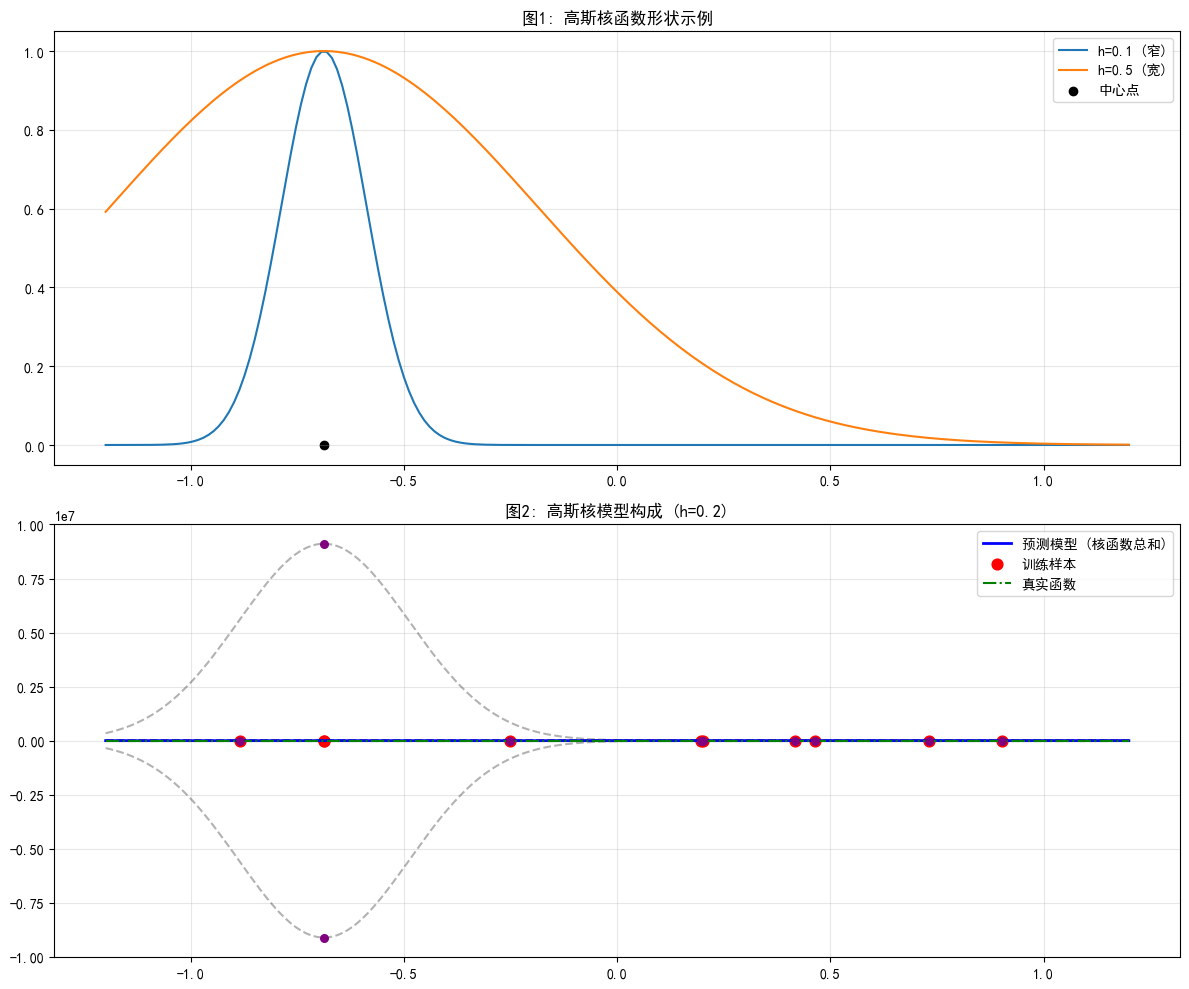

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ==========================================
# 全局设置
# ==========================================
# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 演示 1: 一维线性回归扩展 (多项式与三角基函数)
# 源自图片: efe8615471bd946e05f2ba062f7bf3b0.jpg
# ==========================================
def demo_1d_basis_expansion():
    print("\n--- 正在运行演示 1: 一维基函数扩展回归 ---")
    
    # 1. 定义真实函数
    def true_function(x):
        return np.sin(1.5 * np.pi * x)

    # 2. 生成数据
    np.random.seed(42)
    n_samples = 30
    X_train = np.sort(np.random.rand(n_samples))
    y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)
    
    X_test = np.linspace(0, 1, 100)
    y_true = true_function(X_test)

    # 3. 定义基函数
    def polynomial_basis(x, degree):
        return np.column_stack([x**d for d in range(degree + 1)])

    def trigonometric_basis(x, degree):
        basis = [np.ones_like(x)]
        for k in range(1, degree + 1):
            basis.append(np.sin(2 * np.pi * k * x))
            basis.append(np.cos(2 * np.pi * k * x))
        return np.column_stack(basis)

    # 4. 训练模型
    # 简单线性
    model_simple = LinearRegression()
    model_simple.fit(polynomial_basis(X_train, 1), y_train)
    y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

    # 多项式 (degree=5)
    degree = 5
    model_poly = LinearRegression()
    model_poly.fit(polynomial_basis(X_train, degree), y_train)
    y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

    # 三角基 (k=3)
    k = 3
    model_trig = LinearRegression()
    model_trig.fit(trigonometric_basis(X_train, k), y_train)
    y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

    # 5. 可视化
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, color='blue', label='训练样本')
    plt.plot(X_test, y_true, color='black', label='真实函数')
    plt.plot(X_test, y_pred_simple, 'r--', label='简单线性')
    plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式 (degree={degree})')
    plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基 (k={k})')
    
    plt.title('演示1: 线性回归扩展模型对比')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 演示 2: 二维多项式回归 (3D 曲面拟合)
# 源自图片: 66ee96554a8ecf8cbb90e7a8a6a623ab.jpg
# ==========================================
def demo_2d_surface_fitting():
    print("\n--- 正在运行演示 2: 二维多项式回归 (3D) ---")

    # 1. 定义真实二元函数
    def true_function_2d(x1, x2):
        return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

    # 2. 生成数据
    n_train = 100
    X_train = np.random.uniform(-1, 1, (n_train, 2))
    y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
    y_train += np.random.normal(0, 0.1, n_train)

    # 生成测试网格
    n_test = 50
    x1_mesh = np.linspace(-1, 1, n_test)
    x2_mesh = np.linspace(-1, 1, n_test)
    x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
    X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
    y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

    # 3. 特征工程
    def map_features(X, degree):
        x1, x2 = X[:, 0], X[:, 1]
        features = []
        for i in range(1, degree + 1):
            for j in range(i + 1):
                 term = (x1 ** (i - j)) * (x2 ** j)
                 features.append(term)
        return np.column_stack(features)

    # 4. 训练 (Degree=3)
    degree = 3
    model = LinearRegression()
    model.fit(map_features(X_train, degree), y_train)
    y_predict = model.predict(map_features(X_test, degree))
    
    mse = mean_squared_error(y_true, y_predict)
    print(f"3D曲面拟合 MSE: {mse:.4f}")

    # 5. 可视化
    fig = plt.figure(figsize=(12, 5))
    
    # 真实曲面
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
    ax1.set_title('真实函数曲面')
    
    # 预测曲面
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
    ax2.set_title(f'预测曲面 (MSE: {mse:.4f})')
    
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()

# ==========================================
# 演示 3: 高斯核模型 (Gaussian Kernel Model)
# 源自图片: db65d230...jpg & 8dad8f00...jpg
# ==========================================
def demo_gaussian_kernel():
    print("\n--- 正在运行演示 3: 高斯核模型回归 ---")

    # 1. 定义函数与生成数据
    def true_function_1d(x):
        return np.sin(1 * np.pi * x) + 0.5 * x

    np.random.seed(42)
    n_samples = 10 
    x_train = np.sort(np.random.uniform(-1, 1, n_samples))
    y_train = true_function_1d(x_train) + 0.2 * np.random.randn(n_samples)
    x_test = np.linspace(-1.2, 1.2, 200)
    y_true = true_function_1d(x_test)

    # 2. 核函数定义
    def gaussian_kernel(x, c, h):
        distance_sq = (x - c) ** 2
        return np.exp(-distance_sq / (2 * h ** 2))

    def kernel_features(x, centers, h):
        n_centers = len(centers)
        features = np.zeros((len(x), n_centers))
        for j in range(n_centers):
            features[:, j] = gaussian_kernel(x, centers[j], h)
        return features

    # 3. 训练模型
    h = 0.2
    # 使用训练样本本身作为核函数的中心
    X_train_k = kernel_features(x_train, x_train, h)
    X_test_k = kernel_features(x_test, x_train, h)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_train_k, y_train)
    theta = model.coef_
    y_pred = model.predict(X_test_k)

    print(f"学习到的参数 theta: {theta.round(2)}")

    # 4. 可视化
    plt.figure(figsize=(12, 10))

    # 子图1: 核函数形状示例
    plt.subplot(2, 1, 1)
    c_demo = x_train[2]
    plt.plot(x_test, gaussian_kernel(x_test, c_demo, h=0.1), label=f'h=0.1 (窄)')
    plt.plot(x_test, gaussian_kernel(x_test, c_demo, h=0.5), label=f'h=0.5 (宽)')
    plt.scatter([c_demo], [0], c='k', label='中心点')
    plt.title('图1: 高斯核函数形状示例')
    plt.legend()
    plt.grid(alpha=0.3)

    # 子图2: 模型构成
    plt.subplot(2, 1, 2)
    # 绘制每个加权后的核
    for j in range(n_samples):
        k_j = theta[j] * gaussian_kernel(x_test, x_train[j], h)
        plt.plot(x_test, k_j, 'k--', alpha=0.3)
        plt.scatter(x_train[j], theta[j], c='purple', s=30, zorder=3)
    
    plt.plot(x_test, y_pred, 'b-', linewidth=2, label='预测模型 (核函数总和)')
    plt.scatter(x_train, y_train, c='red', s=60, label='训练样本')
    plt.plot(x_test, y_true, 'g-.', label='真实函数')
    
    plt.title(f'图2: 高斯核模型构成 (h={h})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 主程序入口
# ==========================================
if __name__ == "__main__":
    # 依次调用三个演示函数
    # 1. 一维基函数扩展
    demo_1d_basis_expansion()
    
    # 2. 二维曲面拟合
    demo_2d_surface_fitting()
    
    # 3. 高斯核模型
    demo_gaussian_kernel()

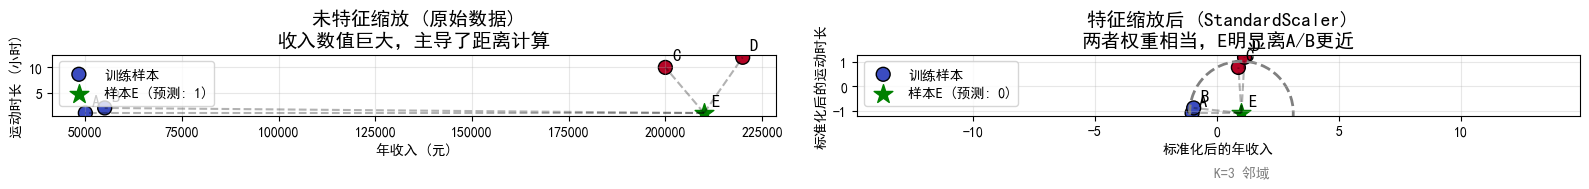

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 设置中文字体 (根据系统选择，Windows通常是SimHei, Mac是Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 准备数据 ---
# 特征：[年收入(元), 运动时长(小时)]
X_train = np.array([
    [50000, 1],
    [55000, 2],
    [200000, 10],
    [220000, 12]
])
# 标签：0:不买, 1:买
y_train = np.array([0, 0, 1, 1]) 
labels = ['A', 'B', 'C', 'D']

# 待预测样本 E
X_new = np.array([[210000, 1]]) 

# --- 2. 计算缩放后的数据 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# --- 3. 训练两个模型获取预测结果 ---
# 模型1：使用原始数据 (K=3)
knn_raw = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)[0]

# 模型2：使用标准化数据 (K=3)
knn_scaled = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_new_scaled)[0]

# --- 开始绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ================= 左图：未缩放 (原始数据) =================
ax1 = axes[0]
# 绘制训练点
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=100, 
            cmap='coolwarm', edgecolors='k', label='训练样本')
# 绘制新样本 E
ax1.scatter(X_new[:, 0], X_new[:, 1], c='green', s=200, marker='*', 
            label=f'样本E (预测: {pred_raw})')

# 标注点名称
for i, txt in enumerate(labels):
    ax1.annotate(txt, (X_train[i, 0], X_train[i, 1]), xytext=(5, 5), 
                 textcoords='offset points', fontsize=12)
ax1.annotate("E", (X_new[0, 0], X_new[0, 1]), xytext=(5, 5), 
             textcoords='offset points', fontsize=12, fontweight='bold')

# 画连接线 (表示距离)
for i in range(len(X_train)):
    ax1.plot([X_new[0, 0], X_train[i, 0]], [X_new[0, 1], X_train[i, 1]], 'k--', alpha=0.3)

ax1.set_title("未特征缩放 (原始数据)\n收入数值巨大，主导了距离计算", fontsize=14)
ax1.set_xlabel("年收入 (元)")
ax1.set_ylabel("运动时长 (小时)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
# 注意：为了体现比例失调，不强制 axis('equal')

# ================= 右图：标准化后 =================
ax2 = axes[1] #
# 绘制训练点
ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            s=100, cmap='coolwarm', edgecolors='k', label='训练样本')
# 绘制新样本 E
ax2.scatter(X_new_scaled[:, 0], X_new_scaled[:, 1], c='green', s=200, marker='*', 
            label=f'样本E (预测: {pred_scaled})')

# 标注点名称
for i, txt in enumerate(labels):
    ax2.annotate(txt, (X_train_scaled[i, 0], X_train_scaled[i, 1]), xytext=(5, 5), 
                 textcoords='offset points', fontsize=12)
ax2.annotate("E", (X_new_scaled[0, 0], X_new_scaled[0, 1]), xytext=(5, 5), 
             textcoords='offset points', fontsize=12, fontweight='bold')

# 画连接线
for i in range(len(X_train_scaled)):
    ax2.plot([X_new_scaled[0, 0], X_train_scaled[i, 0]], 
             [X_new_scaled[0, 1], X_train_scaled[i, 1]], 'k--', alpha=0.3)

# 画圆圈：展示最近的3个邻居
# 计算E到所有点的距离
dists = np.linalg.norm(X_train_scaled - X_new_scaled, axis=1)
# 第3近的距离稍微加一点作为半径
radius = sorted(dists)[2] + 0.1 

circle = plt.Circle((X_new_scaled[0, 0], X_new_scaled[0, 1]), radius, 
                    color='gray', fill=False, linestyle='--', linewidth=2)
ax2.add_artist(circle)
ax2.text(X_new_scaled[0, 0], X_new_scaled[0, 1]-radius-0.5, "K=3 邻域", 
         ha='center', color='gray')

ax2.set_title("特征缩放后 (StandardScaler)\n两者权重相当，E明显离A/B更近", fontsize=14)
ax2.set_xlabel("标准化后的年收入")
ax2.set_ylabel("标准化后的运动时长")
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.axis('equal') # 保持比例一致，这样圆才是圆

plt.tight_layout()
plt.show()

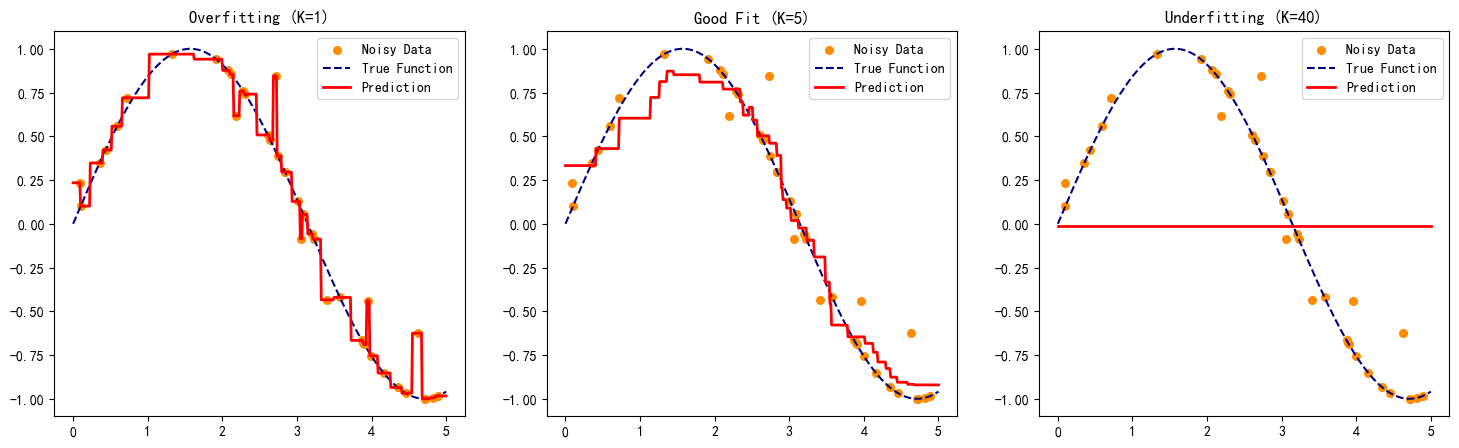

In [ ]:
#kNN回归示例：展示不同K值下的欠拟合、正常拟合和过拟合情况
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor # 注意：这里改成了 Regressor

# ================= 数据准备 (模拟生成数据) =================
# 生成样本数据
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0) # 40个训练点
T = np.linspace(0, 5, 500)[:, np.newaxis]      # 测试点（用于画平滑曲线）
y = np.sin(X).ravel()                          # 真实值
y[::5] += 1 * (0.5 - np.random.rand(8))        # 每5个点加一点噪声

# ================= 你的代码逻辑补全 =================
# K=1: 过拟合 (捕捉到了所有噪声)
# K=5: 正常拟合
# K=40: 欠拟合 (平滑成一条均值线)
k_values = [1, 5, 40]
titles = ["Overfitting (K=1)", "Good Fit (K=5)", "Underfitting (K=40)"]

plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    # 训练模型 (改为 Regressor 以进行连续值预测)
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X, y)
    y_pred = knn.predict(T)
    
    # 绘图
    ax = plt.subplot(1, 3, i + 1)
    
    # 1. 画出带噪声的训练点
    ax.scatter(X, y, color='darkorange', label='Noisy Data', s=30)
    
    # 2. 画出真实函数 (补全部分：这里假设底层函数是 sin)
    ax.plot(T, np.sin(T), color='navy', linestyle='--', label='True Function')
    
    # 3. 画出预测结果 (补全部分)
    ax.plot(T, y_pred, color='red', linewidth=2, label='Prediction')
    
    # 设置装饰
    plt.legend()
    plt.title(titles[i])

plt.show()

In [2]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import shutil
import os
import pandas as pd # 补充导入，用于处理数据展示

# --- 1. 环境清理与数据准备 (来自图 image_467880) ---
# 清理旧数据 (可选，方便多次运行)
if os.path.exists("mlruns"):
    try:
        shutil.rmtree("mlruns")
    except Exception as e:
        print(f"清理 mlruns 文件夹失败: {e}")

# 加载数据
data = load_iris()
X = data.data
y = data.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"数据准备完成: 训练集 {len(X_train)}, 测试集 {len(X_test)}")

# --- 2. 设置实验 (来自图 image_467847) ---
mlflow.set_experiment("KNN_Optimization_Experiment")

k_values = [1, 3, 5, 7, 9]

print("\n开始 MLflow 实验循环...")

for k in k_values:
    # 开启一个 MLflow Run
    with mlflow.start_run(run_name=f"KNN_k_{k}"):
        
        # A. 记录超参数
        mlflow.log_param("n_neighbors", k)
        mlflow.log_param("algorithm", "auto")
        
        # B. 训练模型
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        
        # --- [修复] 补全图片中缺失的预测与评估步骤 ---
        # 原图中直接跳到了 infer_signature(preds)，但 preds 还没计算
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        
        # 记录指标 (Metric)
        mlflow.log_metric("accuracy", acc)
        
        # --- [新增] E. 构建模型签名和输入样例 (来自图 image_46757e) ---
        # 签名告诉 MLflow：输入是什么形状，输出是什么形状
        # 注意：这里通常用 X_test 和 preds 来推断签名，或者用 X_train 和 model.predict(X_train)
        signature = infer_signature(X_train, model.predict(X_train))
        
        # 样例让其他使用者知道数据长什么样
        input_example = X_train[:5]
        
        # F. 记录模型 (带签名)
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="knn_model",   # 显示指定参数名
            signature=signature,         # 传入签名
            input_example=input_example  # 传入样例
        )
        
        print(f"K={k}, Accuracy={acc:.4f} -> 已记录 (含Signature)")

print("\n所有实验运行结束！可以使用 'mlflow ui' 命令查看结果。")

d:\conda_envs\syc\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/12/03 11:29:43 INFO mlflow.tracking.fluent: Experiment with name 'KNN_Optimization_Experiment' does not exist. Creating a new experiment.


数据准备完成: 训练集 120, 测试集 30

开始 MLflow 实验循环...


2025/12/03 11:29:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\conda_envs\syc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/12/03 11:29:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=1, Accuracy=1.0000 -> 已记录 (含Signature)


2025/12/03 11:29:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2025/12/03 11:29:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=5, Accuracy=1.0000 -> 已记录 (含Signature)


2025/12/03 11:30:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=7, Accuracy=0.9667 -> 已记录 (含Signature)


K=9, Accuracy=1.0000 -> 已记录 (含Signature)

所有实验运行结束！可以使用 'mlflow ui' 命令查看结果。


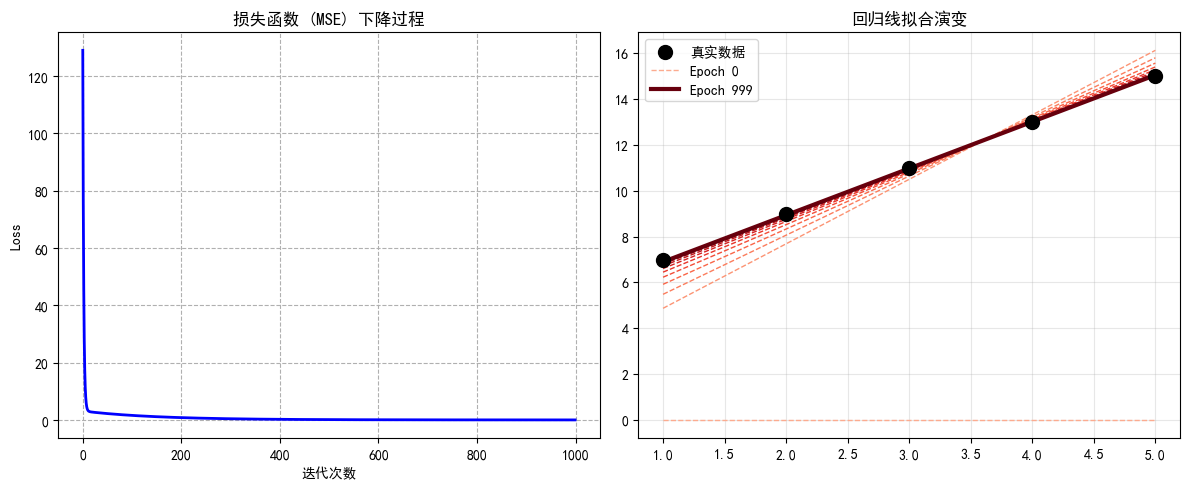

In [3]:
#静态数据大屏可视化
import numpy as np
import matplotlib.pyplot as plt

# 设置字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据
X = np.array([1, 2, 3, 4, 5])
y = np.array([7, 9, 11, 13, 15]) # 真实关系 y = 2x + 5

# 2. 初始化
w = 0.0
b = 0.0
lr = 0.01
epochs = 1000
n = len(X)

loss_history = []
params_history = [] # 记录每一步 w 和 b

# 3. 梯度下降循环
for i in range(epochs):
    y_pred = w * X + b
    loss = (1/n) * np.sum((y - y_pred)**2)
    
    loss_history.append(loss)
    
    # 每100次或最后一次记录参数用于画线
    if i % 100 == 0 or i == epochs - 1:
        params_history.append((i, w, b))
        
    # 计算梯度
    dw = -(2/n) * np.sum(X * (y - y_pred))
    db = -(2/n) * np.sum(y - y_pred)
    
    # 更新
    w = w - lr * dw
    b = b - lr * db

# 4. 绘图
plt.figure(figsize=(12, 5))

# 图1: 损失函数下降过程
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('损失函数 (MSE) 下降过程')
plt.xlabel('迭代次数')
plt.ylabel('Loss')
plt.grid(True, linestyle='--')

# 图2: 回归线拟合过程
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='black', s=100, label='真实数据', zorder=10)

# 使用颜色映射：浅色是早期，深红是后期
colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(params_history)))

for idx, (epoch, w_hist, b_hist) in enumerate(params_history):
    y_line = w_hist * X + b_hist
    label = f'Epoch {epoch}' if epoch == 0 or epoch == epochs-1 else None
    style = '--' if epoch < epochs-1 else '-'
    width = 1 if epoch < epochs-1 else 3
    
    plt.plot(X, y_line, color=colors[idx], linestyle=style, linewidth=width, label=label)

plt.title('回归线拟合演变')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

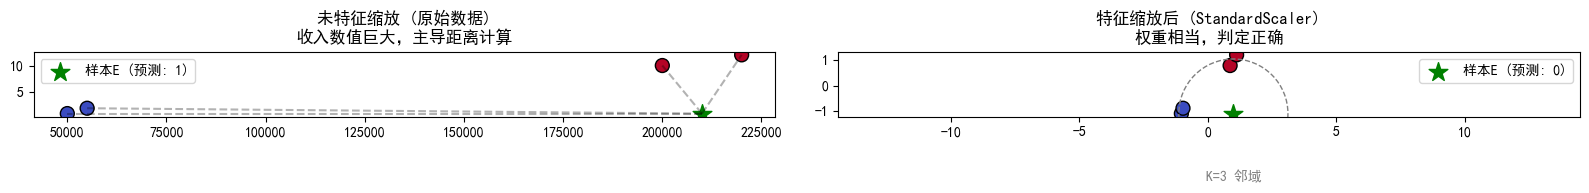

In [ ]:
# 岭回归对抗多重共线性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 设置字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 准备数据 ---
# 特征：[年收入, 运动时长]
X_train = np.array([[50000, 1], [55000, 2], [200000, 10], [220000, 12]])
y_train = np.array([0, 0, 1, 1]) 
labels = ['A', 'B', 'C', 'D']
X_new = np.array([[210000, 1]]) # 样本E

# --- 2. 数据标准化 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# --- 3. 训练模型并预测 ---
# 原始数据训练
knn_raw = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)[0]
# 标准化数据训练
knn_scaled = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_new_scaled)[0]

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：未缩放
ax1 = axes[0]
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=100, cmap='coolwarm', edgecolors='k')
ax1.scatter(X_new[:, 0], X_new[:, 1], c='green', s=200, marker='*', label=f'样本E (预测: {pred_raw})')
# 连线
for i in range(len(X_train)):
    ax1.plot([X_new[0, 0], X_train[i, 0]], [X_new[0, 1], X_train[i, 1]], 'k--', alpha=0.3)
ax1.set_title("未特征缩放 (原始数据)\n收入数值巨大，主导距离计算")
ax1.legend()

# 右图：标准化后
ax2 = axes[1]
ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, s=100, cmap='coolwarm', edgecolors='k')
ax2.scatter(X_new_scaled[:, 0], X_new_scaled[:, 1], c='green', s=200, marker='*', label=f'样本E (预测: {pred_scaled})')
# 画邻域圆
dists = np.linalg.norm(X_train_scaled - X_new_scaled, axis=1)
radius = sorted(dists)[2] + 0.1
circle = plt.Circle((X_new_scaled[0, 0], X_new_scaled[0, 1]), radius, color='gray', fill=False, linestyle='--')
ax2.add_artist(circle)
ax2.text(X_new_scaled[0, 0], X_new_scaled[0, 1]-radius-0.5, "K=3 邻域", ha='center', color='gray')
ax2.set_title("特征缩放后 (StandardScaler)\n权重相当，判定正确")
ax2.axis('equal') 
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 岭回归解决多重共线性
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge

# 1. 构造高度共线的数据
# 特征 x1 和 x2 极其相似
X = np.array([[10, 10.1], [20, 20.1], [30, 29.9]])
y = np.array([20, 40, 60]) # 目标 y ≈ x1 + x2

# 2. 普通线性回归
lr = LinearRegression()
lr.fit(X, y)
print(f"普通线性回归系数: {lr.coef_}") 
# 可能输出如 [100, -98]，系数很大且符号相反，这就是过拟合/共线性的表现

# 3. 岭回归 (L2 正则化)
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
print(f"岭回归系数: {ridge.coef_}") 
# 输出如 [0.99, 1.01]，系数更平滑，符合物理意义

普通线性回归系数: [ 2.00000000e+00 -1.74277034e-15]
岭回归系数: [1.01081099 0.99407571]


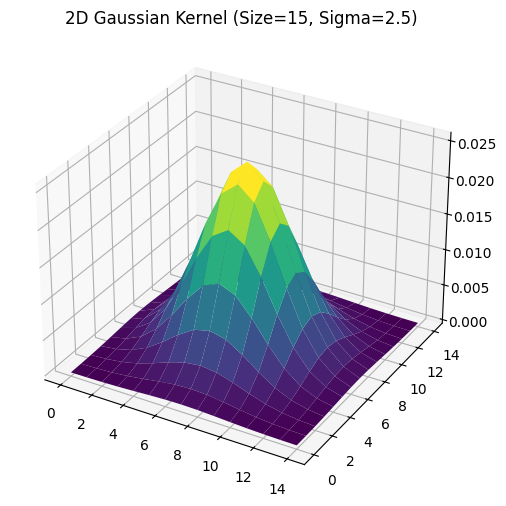

In [1]:
#二维高斯核函数回归示例
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_gaussian_kernel(kernel_size=5, sigma=1.0):
    """生成二维高斯核"""
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)  # 归一化

# 参数设置
k_size = 15
sigma = 2.5
kernel = get_gaussian_kernel(k_size, sigma)

# 绘图
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

x, y = np.meshgrid(np.arange(k_size), np.arange(k_size))
ax.plot_surface(x, y, kernel, cmap='viridis', linewidth=0)
ax.set_title(f'2D Gaussian Kernel (Size={k_size}, Sigma={sigma})')
plt.show()

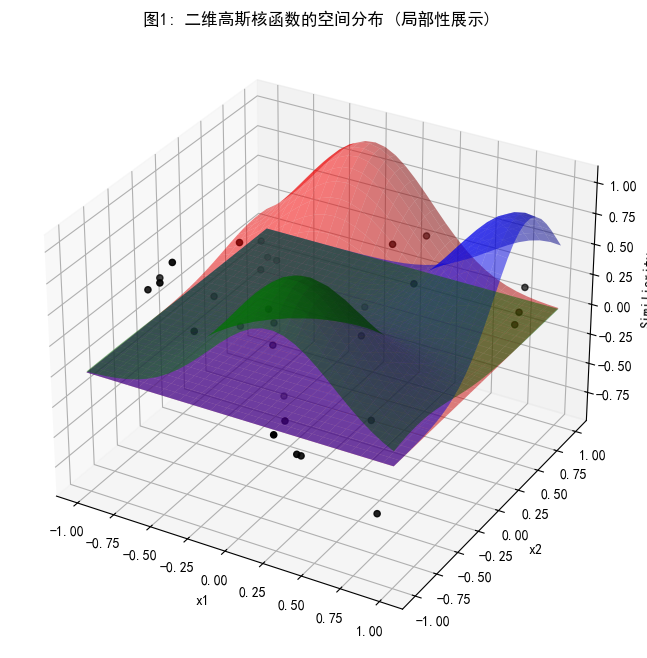

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from matplotlib.colors import ListedColormap

# --------------------------
# 1. 设置中文显示问题
# --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# --------------------------
# 2. 定义真实函数 (被拟合的目标)
# --------------------------
def true_function_2d(x):
    """
    一个二维非线性函数，作为我们想要拟合的目标函数。
    x: 输入数据 (n_samples, 2)
    """
    # 这里的公式看起来像是 sin(pi*x1) * sin(pi*x2)
    return np.sin(x[:, 0] * np.pi) * np.sin(x[:, 1] * np.pi)

# --------------------------
# 3. 生成训练数据 (加上噪声)
# --------------------------
np.random.seed(42)  # 设置随机种子，保证结果可复现
n_samples = 30
# 在 [-1, 1] 区间内生成均匀分布的随机样本
X_train = np.random.uniform(-1, 1, (n_samples, 2))
# 生成目标值 y，并加入少量高斯噪声
y_train = true_function_2d(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据 (用于绘图的网格)
x1_test = np.linspace(-1, 1, 30)
x2_test = np.linspace(-1, 1, 30)
x1_grid, x2_grid = np.meshgrid(x1_test, x2_test)
X_test = np.c_[x1_grid.ravel(), x2_grid.ravel()] # 拉平并组合成 (n, 2)
y_test = true_function_2d(X_test)

# --------------------------
# 4. 定义高斯核函数 (Similarity)
# --------------------------
def gaussian_kernel_2d(x, center, h):
    """
    计算样本点 x 到中心点 center 的高斯核相似度。
    h: 带宽参数 (控制钟形曲线的宽度)
    """
    # 欧式距离的平方
    distance_sq = np.sum((x - center) ** 2, axis=1)
    return np.exp(-distance_sq / (2 * h**2))

# --------------------------
# 5. 定义构建核特征矩阵的函数 (RBF特征)
# --------------------------
def kernel_model_features_2d(X, centers, h):
    """
    将输入数据映射到特征空间。每个样本会变成一个 len(centers) 维的向量。
    """
    n_samples = len(X)
    n_centers = len(centers)
    
    features = np.zeros((n_samples, n_centers)) # 初始化特征矩阵
    
    for j in range(n_centers):
        # 计算所有样本到第 j 个中心的相似度
        features[:, j] = gaussian_kernel_2d(X, centers[j], h)
        
    return features

# --------------------------
# 6. 训练线性模型并预测 (核心逻辑)
# --------------------------
h = 0.4 # 带宽参数，控制每个核的影响范围
# 这里直接使用所有训练样本作为“中心” (类似 Kernel Ridge Regression 的思路)
centers = X_train 
b = len(centers)

# 计算训练集和测试集的核特征
X_train_kernel = kernel_model_features_2d(X_train, centers, h)
X_test_kernel = kernel_model_features_2d(X_test, centers, h)

# 使用线性回归拟合特征
# fit_intercept=False 因为通常核方法通过核函数的线性组合来拟合，或者截距项隐含在其中
model_kernel = LinearRegression(fit_intercept=False)
model_kernel.fit(X_train_kernel, y_train)
theta = model_kernel.coef_ # 获取学到的权重系数

# 预测 (虽然这段代码主要目的是绘图，但这步是标准流程)
y_pred_kernel = model_kernel.predict(X_test_kernel)

# --------------------------
# 7. 可视化：绘制部分高斯核基函数
# --------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 选取几个特定的中心点来展示它们的“形状”
# 索引是根据图片推测的，可能是 [0, 10, 25] 或类似
selected_centers = [centers[0], centers[10], centers[25]] 
colors = ['red', 'green', 'blue']

for i, c in enumerate(selected_centers):
    # 计算网格上所有点到当前选中中心的高斯核值
    kernel_vals = gaussian_kernel_2d(X_test, c, h)
    
    # 绘制曲面 (Reshape回网格形状)
    ax.plot_surface(x1_grid, x2_grid, kernel_vals.reshape(30, 30), 
                    alpha=0.5, color=colors[i], 
                    label=f'中心 {np.round(c, 2)}')

# 绘制原始训练数据点
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='k', marker='o', label='训练样本')

ax.set_title("图1: 二维高斯核函数的空间分布 (局部性展示)")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Similiarity')
# ax.legend() # 3D图的legend有时显示有问题，根据需要开启
plt.show()

In [2]:
# ... (接上一部分代码的结尾)

# --------------------------
# 5.2 子图2：核模型的预测结果 (3D表面)
# --------------------------
ax2 = fig.add_subplot(2, 2, 2, projection='3d')

# 将预测结果 reshape 回网格形状以便绘图
y_pred_grid = y_pred_kernel.reshape(x1_grid.shape)

# 绘制曲面
surf_pred = ax2.plot_surface(x1_grid, x2_grid, y_pred_grid, 
                             cmap='viridis', alpha=0.8, label='核模型预测')

# 绘制训练样本点 (红色散点，直观显示模型是否“经过”了数据点)
# 注意：这里假设上一段代码定义的变量名为 X_train, y_train
ax2.scatter(X_train[:, 0], X_train[:, 1], y_train, 
            c='r', s=50, alpha=1, label='训练样本')

ax2.set_title('图2: 二维高斯核模型的预测表面', fontsize=12)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('f_theta(x) (预测值)')
# ax2.legend()

# --------------------------
# 5.3 子图3：模型预测与真实函数的差异 (误差热力图)
# --------------------------
ax3 = fig.add_subplot(2, 2, 3)

# 计算预测误差 (y_true 即为上一段代码中的 y_test)
error = (y_pred_kernel - y_test).reshape(x1_grid.shape)

# 绘制误差热力图
# extent 参数确保热力图的坐标轴范围与数据一致
im = ax3.imshow(error, extent=[-1, 1, -1, 1], origin='lower', 
                cmap='coolwarm', alpha=0.8)

plt.colorbar(im, ax=ax3, label='预测误差 (预测值-真实值)')

# 标记训练样本位置 (白色十字，体现样本点附近误差通常较小)
ax3.scatter(X_train[:, 0], X_train[:, 1], c='w', marker='+', s=100, label='训练样本位置')

ax3.set_title('图3: 预测误差热力图 (样本附近误差更小)', fontsize=12)
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
# ax3.legend()

# --------------------------
# 5.4 子图4：核中心数量对模型的影响 (展示参数个数与样本数的关系)
# --------------------------
ax4 = fig.add_subplot(2, 2, 4)

# 测试不同核中心数量 (从5到n_samples) 的模型误差
n_centers_list = range(5, n_samples + 1)
mse_list = []

for n in n_centers_list:
    # 选择前 n 个样本作为中心
    sub_centers = centers[:n]
    
    # 构造特征矩阵并训练
    X_sub = kernel_model_features_2d(X_train, sub_centers, h)
    # fit_intercept=False 保持一致
    model_sub = LinearRegression(fit_intercept=False).fit(X_sub, y_train)
    
    # 计算测试集误差
    X_test_sub = kernel_model_features_2d(X_test, sub_centers, h)
    y_pred_sub = model_sub.predict(X_test_sub)
    mse_list.append(mean_squared_error(y_test, y_pred_sub))

# 绘制误差随核中心数量的变化
ax4.plot(n_centers_list, mse_list, 'o-', color='purple')
ax4.set_title('图4: 核中心数量与模型误差的关系', fontsize=12)
ax4.set_xlabel('按中心数量b (参数个数)')
ax4.set_ylabel('测试集MSE')
ax4.grid(alpha=0.3)

# 添加注释箭头 (坐标根据图中大致位置调整)
ax4.annotate('b=20 附近', xy=(20, mse_list[-1]), xytext=(15, mse_list[0]),
             arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

# --------------------------
# 6. 模型性能评估
# --------------------------
mse_kernel = mean_squared_error(y_test, y_pred_kernel)
print(f"二维高斯核模型的测试集MSE: {mse_kernel:.4f}")
print(f"核函数数量 (参数个数): b = {len(centers)}")
print(f"输入维度: d = 2 (与参数个数无关)")

C:\Users\25711\AppData\Local\Temp\ipykernel_25684\3944930731.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax3, label='预测误差 (预测值-真实值)')


<Figure size 640x480 with 0 Axes>

二维高斯核模型的测试集MSE: 1.7989
核函数数量 (参数个数): b = 30
输入维度: d = 2 (与参数个数无关)


## 最小二乘法

最小二乘法解析解参数theta: [0.9955 1.9665]
sklearn最小二乘参数theta: [0.9955 1.9665]
解析解对应的训练集损失J_LS(theta): 1.8519


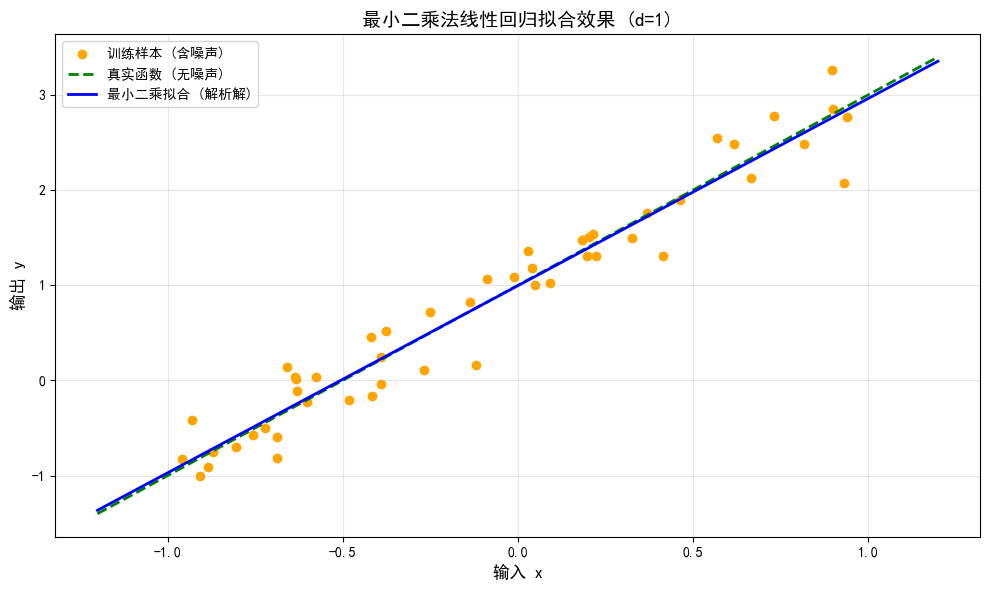

In [6]:
import numpy as np
import matplotlib.pylab as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# --------------------------
# 解决中文显示问题
# --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# --------------------------
# 1. 生成模拟数据 (d维输入，对应训练样本输入(x_i))
# --------------------------
def generate_data(d=1, n_samples=50):
    """
    函数功能: 生成d维输入、1维输出的模拟训练数据，用于验证最小二乘学习法
    参数说明:
    - d: 输入数据的维度 (默认d=1，既一维输入，可扩展到高维)
    - n_samples: 训练样本的数量 (默认50个)
    返回值:
    - x: 输入样本集合, 形状为(n_samples, d), 对应{x_i}
    - y: 输入样本对应的真实标签 (含噪声) , 形状为(n_samples,), 对应{y_i}
    - true_func: 生成标签的真实函数 (无噪声) , 用于后续计算真实值
    """
    np.random.seed(42) # 固定随机种子，保证每次运行生成相同的随机数据，结果可复现
    # 生成d维输入x: n_samples个样本，每个样本d个特征，取值范围[-1,1] (均匀分布)
    X = np.random.uniform(-1, 1, (n_samples, d))
    # 定义真实函数f(x) (根据输入维度d适配，一维和高维分别处理)
    if d == 1:
        true_func = lambda x: 2 * x[:, 0] + 1
    else:
        w_true = np.arange(1, d+1)
        true_func = lambda x: X @ w_true + 0.5 # 矩阵乘法实现线性组合

    # 生成带噪声的标签y: 真实数值 + 0.3倍高斯噪声 (模拟真实数据的测量误差)
    y = true_func(X) + 0.3 * np.random.randn(n_samples)
    return X, y, true_func # 返回输入样本x, 带噪声标签y, 真实函数

# 生成训练数据：默认d=1 (一维输入，便于可视化)，可修改d测试高维场景 (如d=5, 10)
d = 1
x_train, y_train, true_func = generate_data(d=d, n_samples=50)
# 生成测试数据：在[-1.2, 1.2]范围内生成100个密集点，形状调整为(100, d) (适配模型输入格式)
x_test = np.linspace(-1.2, 1.2, 100).reshape(-1, d)
y_true = true_func(x_test) # 计算测试数据的真实值 (无噪声)，作为模型拟合效果的对比基准

# --------------------------
# 2. 定义最小二乘法损失函数 (严格对应公式J_LS(theta) = 1/2 * sum((f_theta(x_i)-y_i)^2))
# --------------------------
def least_squares_loss(theta, x, y, model):
    """
    函数功能：计算最小二乘损失值，量化模型预测与真实标签的偏差
    参数说明：
    - theta: 模型参数向量 (如线性模型的偏置+权重，对应theta)
    - x: 输入样本集合 (形状(n_samples, d))
    - y: 输入样本对应的真实标签 (形状(n_samples,))
    - model: 模型函数 (输入x和theta，返回模型预测值f_theta(x))
    返回值：
    - 最小二乘损失值 (对应J_LS(theta))
    """
    y_pred = model(x, theta) # 调用模型，计算输入x的预测值f_theta(x)
    residual = y_pred - y    # 计算每个样本的残差 (预测误差)，residual = f_theta(x_i) - y_i
    return 0.5 * np.sum(residual ** 2) # 计算损失值: 1/2 * 所有样本残差的平方和 (严格对应公式)

# --------------------------
# 3. 定义模型 (以线性模型为例，对应f_theta(x))
# --------------------------
def linear_model(x, theta):
    """
    函数功能：实现线性模型，计算预测值f_theta(x)
    模型形式：f_theta(x) = theta[0] + theta[1]*x1 + theta[2]*x2 + ... + theta[d]*xd
    参数说明：
    - x: 输入样本集合，形状(n_samples, d)
    - theta: 模型参数向量，形状(d+1,) (theta[0]为偏置b, theta[1:]为各特征的权重w)
    返回值：
    - 模型预测值，形状(n_samples,) (每个样本的预测结果)
    """
    # 给输入x添加偏置项，在x的第一列添加全1的向量，使得模型可以通过矩阵乘法同时计算偏置和权重
    x_with_bias = np.hstack([np.ones((x.shape[0], 1)), x])
    # 利用矩阵乘法计算预测值 = 偏置 + 权重*特征 的线性组合 (对应模型公式)
    return x_with_bias @ theta

# --------------------------
# 4. 最小二乘参数求解 (两种方式：解析解 + sklearn实现，相互验证结果)
# --------------------------
# 方式1：手动实现解析解 (线性模型下最小二乘法的闭式解，对应theta = (X^T X)^(-1) X^T y)
def least_squares_analytical(x, y):
    """
    函数功能：计算线性最小二乘法的解析解 (闭式解)
    公式说明：theta = (X^T X)^(-1) X^T y。其中X为增加偏置项的输入矩阵
    参数说明：
    - x: 输入样本集合 (形状(n_samples, d))
    - y: 真实标签 (形状(n_samples,))
    返回值：
    - theta_analytical: 解析计算得到的参数theta (偏置+权重)
    """
    # 给输入x添加偏置项，得到矩阵X (形状(n_samples, d+1))
    x_with_bias = np.hstack([np.ones((x.shape[0], 1)), x])
    x_t_x = x_with_bias.T @ x_with_bias # 计算 X^T X (矩阵转置与原矩阵相乘)
    x_t_y = x_with_bias.T @ y           # 计算 X^T y (矩阵转置与标签向量相乘)
    # 计算解析解：(X^T X)的逆矩阵 与 X^T y 相乘 (np.linalg.inv求逆矩阵)
    theta_analytical = np.linalg.inv(x_t_x) @ x_t_y
    return theta_analytical

# 调用函数计算解析解，得到最优参数
theta_analytical = least_squares_analytical(x_train, y_train)
# 打印解析解参数 (保留4位小数)，展示学到的偏置项和权重
print(f"最小二乘法解析解参数theta: {theta_analytical.round(4)}")

# 方式2：使用sklearn的LinearRegression实现 (默认采用最小二乘求解，验证手动解析解的正确性)
model_sklearn = LinearRegression() # 初始化线性回归模型 (默认fit_intercept=True, 自动学习偏置)
model_sklearn.fit(x_train, y_train) # 传入训练数据拟合模型，学习最优参数
# 将sklearn模型的参数：intercept_是偏置b[0], coef_是权重w[1:]，拼接后得到完整参数向量theta
theta_sklearn = np.hstack([model_sklearn.intercept_, model_sklearn.coef_])
# 打印sklearn得到的参数 (保留4位小数)，与解析解对比
print(f"sklearn最小二乘参数theta: {theta_sklearn.round(4)}")

# --------------------------
# 5. 模型预测与损失计算 (验证模型拟合效果)
# --------------------------
# 用解析解得到的参数theta，对测试数据进行预测
y_pred_analytical = linear_model(x_test, theta_analytical)
# 用sklearn模型对测试数据进行预测 (直接调用predict方法，无需手动传参)
y_pred_sklearn = model_sklearn.predict(x_test)

# 计算解析解对应的训练集损失 (用前面定义的损失函数计算)
loss_analytical = least_squares_loss(theta_analytical, x_train, y_train, linear_model)
# 打印训练集损失值 (保留4位小数)，量化模型拟合程度
print(f"解析解对应的训练集损失J_LS(theta): {loss_analytical.round(4)}")

# --------------------------
# 6. 可视化结果 (仅d=1时生效，二维场景便于直观理解拟合效果)
# --------------------------
if d == 1:
    plt.figure(figsize=(10, 6))
    
    # 绘制训练样本：橙色散点，代表噪声的训练数据 (x_train, y_train)
    plt.scatter(x_train, y_train, c='orange', label='训练样本 (含噪声)')
    
# ... (接你图片代码的最后一行: plt.scatter(x_train, y_train, ...))

    # 绘制真实函数曲线 (使用测试集的密集点绘制，绿色虚线)
    # y_true 是之前基于 x_test 计算的无噪声真实值
    plt.plot(x_test, y_true, 'g--', label='真实函数 (无噪声)', linewidth=2)

    # 绘制模型预测直线 (使用解析解得到的预测值，蓝色实线)
    # y_pred_analytical 是基于 theta_analytical 对 x_test 的预测
    plt.plot(x_test, y_pred_analytical, 'b-', label='最小二乘拟合 (解析解)', linewidth=2)
    
    # (可选) 如果想对比，也可以画出 sklearn 的预测线，理论上与解析解完全重合
    # plt.plot(x_test, y_pred_sklearn, 'r:', label='Sklearn预测', linewidth=2)

    # 设置图表标题与坐标轴标签
    plt.title('最小二乘法线性回归拟合效果 (d=1)', fontsize=14)
    plt.xlabel('输入 x', fontsize=12)
    plt.ylabel('输出 y', fontsize=12)

    # 显示图例 (显示上述 label 定义的内容)
    plt.legend(fontsize=10)

    # 显示网格，便于观察
    plt.grid(alpha=0.3)

    # 最终显示图像
    plt.tight_layout()
    plt.show()

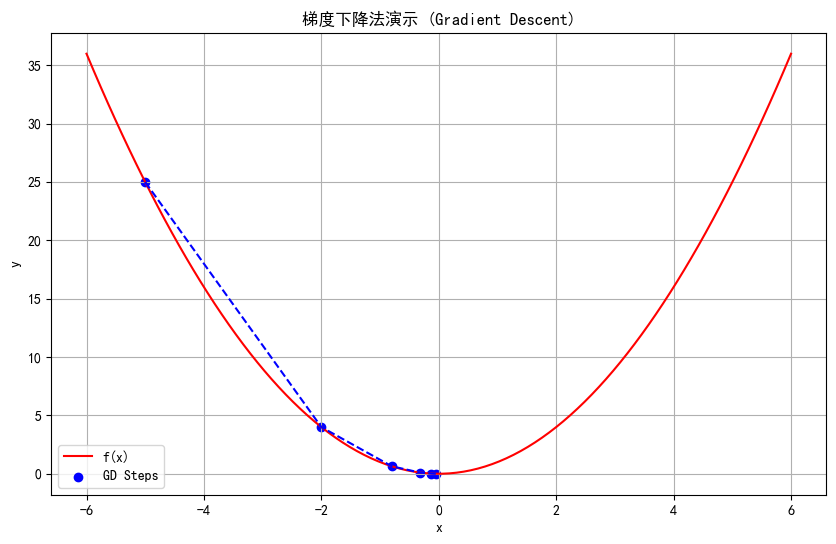

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置中文字体，避免绘图时中文显示乱码
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

# 1. 定义原函数 f(x)
# 从图中看，这应该是一个开口向上的抛物线，例如 f(x) = x^2 或类似的二次函数
def f(x):
    return x ** 2  # 这里假设是简单的 x平方，如果是其他函数可在此修改

# 2. 定义导函数 h(x) (即 f'(x))
# f(x) = x^2 的导数是 2x
def h(x):
    return 2 * x

# 3. 梯度下降算法实现
# x_start: 起始点
# df: 导函数
# epochs: 迭代次数
# lr: 学习率 (learning rate)
def GD(x_start, df, epochs, lr):
    xs = np.zeros(epochs + 1)
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)       # 计算当前点的梯度（导数）
        v = - dx * lr    # 计算下降的步长（负梯度方向 * 学习率）
        x += v           # 更新 x
        xs[i + 1] = x    # 记录轨迹
    return xs

if __name__ == '__main__':
    # 初始化参数
    line_x = np.linspace(-6, 6, 100) # 用于画函数曲线的 x 范围
    line_y = f(line_x)
    
    x_start = -5    # 起始点，从 -5 开始
    epochs = 5      # 迭代 5 次
    lr = 0.3        # 学习率 0.3
    
    # 执行梯度下降，获取 x 的更新轨迹
    x = GD(x_start, h, epochs, lr)
    
    # 绘图部分
    plt.figure(figsize=(10, 6))
    
    # 1. 画出原函数曲线
    plt.plot(line_x, line_y, 'r-', label='f(x)') 
    
    # 2. 画出梯度下降的点（散点图）
    plt.scatter(x, f(x), c='b', label='GD Steps') 
    
    # 3. 画出连接这些点的虚线，表示移动轨迹
    plt.plot(x, f(x), 'b--')
    
    plt.title('梯度下降法演示 (Gradient Descent)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

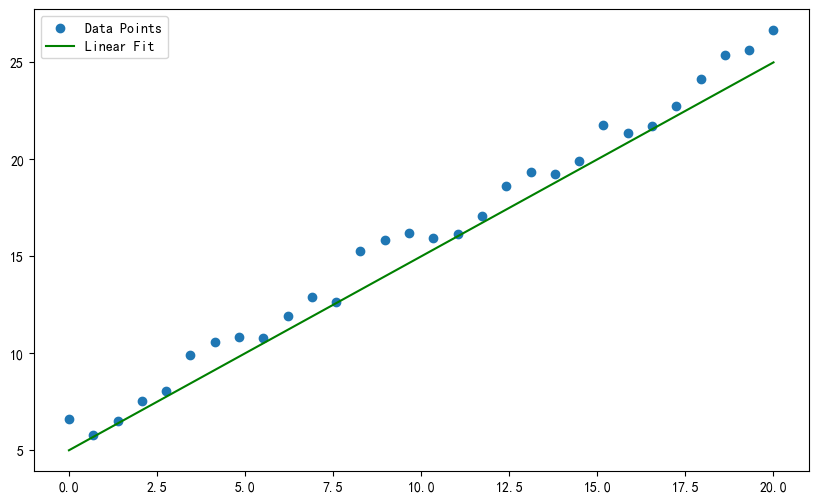

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据
# 生成 0 到 20 之间的 30 个点
X = np.linspace(0, 20, 30) 
# 生成随机噪声
N = np.random.rand(30) * 2 
# 生成 y 值，公式为 y = 1*X + 5 + 噪声 (这里的权重w=1, 偏置b=5)
y = 1 * X + 5 + N

# 2. 绘制图形
plt.figure(figsize=(10, 6))
# 绘制散点图 (真实数据)
plt.scatter(X, y, label='Data Points')
# 绘制拟合直线 (理论值)
plt.plot(X, 1*X + 5, color='green', label='Linear Fit')

plt.legend()
plt.show()

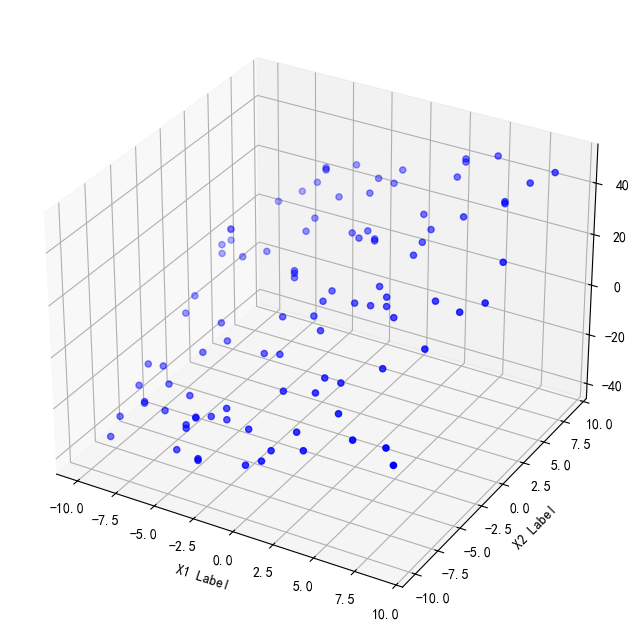

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# 导入 3D 绘图工具
from mpl_toolkits.mplot3d import Axes3D 

# 1. 准备数据
# 生成 100 个 -10 到 10 之间的随机整数作为 x1 和 x2
x1 = np.random.randint(-10, 10, 100)
x2 = np.random.randint(-10, 10, 100)
# 定义 y 的生成规则：y = 2*x1 + 3*x2 + 4 + 噪声
y = 2 * x1 + 3 * x2 + 4 + np.random.rand(100) * 5

# 2. 绘制 3D 散点图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制散点，颜色使用 'blue'
ax.scatter(x1, x2, y, c='b', marker='o')

ax.set_xlabel('X1 Label')
ax.set_ylabel('X2 Label')
ax.set_zlabel('Y Label')

plt.show()

In [ ]:
from sklearn.datasets import fetch_california_housing
#加载数据
california_housing = fetch_california_housing()

# 数据特征
X = california_housing.data

# 数据日标变量
y = california_housing. target

# 特征名称
feature_names = california_housing.feature_names

#从scikit-Learn中大于用于数据集划分的函数
from sklearn.model_selection import train_test_split

#从scikit-Leanrn库中导入交叉验证评分的函数
from sklearn.model_selection import cross_val_score

#导入panbdas库,用于数据处理与分析
import pandas as pd

#读取数据
data = pd.read_csv('./data/housevalue.csv', encoding='utf-8')
data.columns=['住户收入中位数','房屋使用年代中位数','平均房间数目',"平均卧室数目","街区人口","平均入住率","街区的维度","街区的经度","房屋价格"]

"""
MedInc:该街区住户的收入中位数
HouseAge:该街区房屋使用年代的中位数
AveRooms:该街区平均房间数目
AveBadrms:该街区平均的卧室数日
Population:街区人口
AveOccup:平均入住率
Latitude:街区的维度
Longitude:街区的经度
"""

data

,住户收入中位数,房屋使用年代中位数,平均房间数目,平均卧室数目,街区人口,平均入住率,街区的维度,街区的经度,房屋价格
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25,5.045455,1.133333,845,2.560606,39.48,-121.09,0.781
20636,2.5568,18,6.114035,1.315789,356,3.122807,39.49,-121.21,0.771
20637,1.7000,17,5.205543,1.120092,1007,2.325635,39.43,-121.22,0.923
20638,1.8672,18,5.329513,1.171920,741,2.123209,39.43,-121.32,0.847


In [ ]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(data.iloc[:, : -1], data.iloc[:, -1], test_size=0.3, random_state=42)
print(Xtest.head())
print(Xtrain.head())
# scikit-learn库中导入线性回归模型
from sklearn.linear_model import LinearRegression as LR
reg = LR().fit(Xtrain, Ytrain)
yhat = reg.predict(Xtest)
print(yhat)


       住户收入中位数  房屋使用年代中位数    平均房间数目    平均卧室数目  街区人口     平均入住率  街区的维度   街区的经度
20046   1.6812         25  4.192201  1.022284  1392  3.877437  36.06 -119.01
3024    2.5313         30  5.039384  1.193493  1565  2.679795  35.14 -119.46
15663   3.4801         52  3.977155  1.185877  1310  1.360332  37.80 -122.44
20484   5.7376         17  6.163636  1.020202  1705  3.444444  34.28 -118.72
9814    3.7250         34  5.492991  1.028037  1063  2.483645  36.62 -121.93
       住户收入中位数  房屋使用年代中位数    平均房间数目    平均卧室数目  街区人口     平均入住率  街区的维度   街区的经度
7061    4.1312         35  5.882353  0.975490  1218  2.985294  33.93 -118.02
14689   2.8631         20  4.401210  1.076613   999  2.014113  32.79 -117.09
17323   4.2026         24  5.617544  0.989474   731  2.564912  34.59 -120.14
10056   3.1094         14  5.869565  1.094203   302  2.188406  39.26 -121.00
15750   3.3068         52  4.801205  1.066265  1526  2.298193  37.77 -122.45


array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133], shape=(6192,))

In [7]:
reg.coef_

array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
       -7.75740403e-07, -3.37002667e-03, -4.18536746e-01, -4.33687976e-01])

In [8]:
[*zip(Xtrain.columns, reg.coef_)] #查看各特征对应的系数

[('住户收入中位数', np.float64(0.4458225653145767)),
 ('房屋使用年代中位数', np.float64(0.009681867985884066)),
 ('平均房间数目', np.float64(-0.12209511172380835)),
 ('平均卧室数目', np.float64(0.7785995570174045)),
 ('街区人口', np.float64(-7.757404029074963e-07)),
 ('平均入住率', np.float64(-0.003370026670696835)),
 ('街区的维度', np.float64(-0.41853674648955086)),
 ('街区的经度', np.float64(-0.43368797591427566))]

In [10]:
reg.intercept_ #截距
reg.n_features_in_ #特征数量
reg.feature_names_in_ #特征名称
reg.singular_ #奇异值
reg.rank_ #矩阵秩


8

In [11]:
#计算均方差
from sklearn.metrics import mean_squared_error as MSE
mse = MSE(Ytest, yhat)
print("均方误差为: ", mse)


均方误差为:  0.5305677824958456


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(
# 线性回归模型
fit_intercept=True,#核心参数:是否拟合截距(默认True,fy=N1x1+w2x2+b)
copy_X=True,# 是否赋值特征矩阵(默认True,避免修改原始数据)
n_jobs=None # 并行计意数量(默认None,单线程:数据可设为-1使用所有CPU)
)
model.fit(Xtrain,Ytrain) #用训练集训练模型
cross_val_score(reg, X,y, cv=10, scoring='neg_mean_absolute_error')

from sklearn.metrics import mean_absolute_error as MAE
MAE(yhat, Ytest)

# 计算均方误差
from sklearn.metrics import mean_squared_error as MSE
mse = MSE(yhat, Ytest)
y. max()
y.min()
print("Mean Squared Error:", mse)
mse_scores = -cross_val_score(model, X, y, cv=10)
# 交叉验证
# mse_scores = -cross_val_score(model, X, y, cv=10, scoring='ng_mean_squared_error')
print("Corss-validated Mean Squared Error Scores:", mse_scores)


Mean Squared Error: 0.5305677824958456
Corss-validated Mean Squared Error Scores: [-0.48254494 -0.61416063 -0.42274892 -0.48178521 -0.55705986 -0.5412919
 -0.47496038 -0.45844938 -0.48177943 -0.59528796]


In [13]:
from sklearn.metrics import r2_score
r2_score(Ytest, yhat)

0.5957702325915609

In [16]:
#模型评估与交叉验证
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score

# 假设 Ytest 和 yhat 已经在之前的步骤中定义
# r2_score(Ytest, yhat)
# 或者使用命名参数
r2_score(y_true=Ytest, y_pred=yhat)

# 使用交叉验证计算平均分
# 注意：这里的 reg, X, y 需要在上下文定义
cross_val_score(reg, X, y, cv=10, scoring="r2").mean()

np.float64(0.5110068610523784)

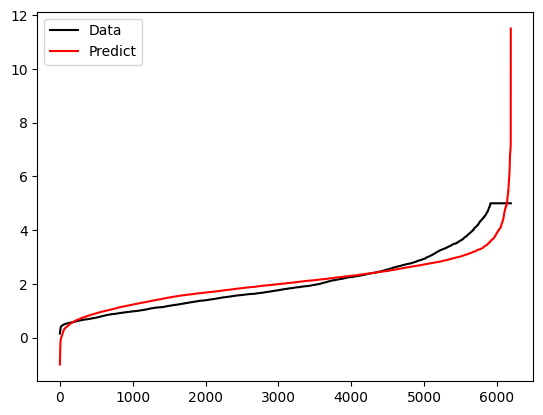

In [17]:
import matplotlib.pyplot as plt

# 对 Ytest 进行排序以获得平滑的曲线对比
sorted_Ytest = sorted(Ytest)
sorted_yhat = sorted(yhat) # 注意：通常对比时只排序真实值，预测值对应排序，但图中似乎是分别排序对比分布

plt.plot(range(len(Ytest)), sorted(Ytest), c="black", label="Data")
plt.plot(range(len(yhat)), sorted(yhat), c="red", label="Predict")
plt.legend()
plt.show()

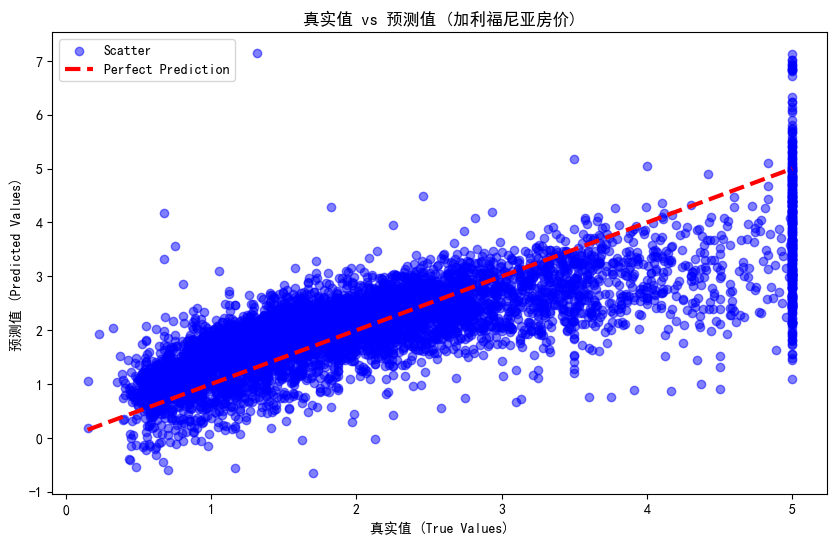

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. 设置 Matplotlib 中文显示
# 'SimHei' 是黑体，如果在 Linux/Mac 上报错，可改为 'Arial Unicode MS' 或其他支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 2. 导入数据
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

# 3. 划分训练集和测试集
# random_state=420 是为了复现结果
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.3, random_state=420)

# 4. 建模与训练
reg = LinearRegression().fit(Xtrain, Ytrain)

# 5. 进行预测
yhat = reg.predict(Xtest)

# 6. 可视化：真实值 vs 预测值
plt.figure(figsize=(10, 6))

# 绘制散点图
plt.scatter(Ytest, yhat, alpha=0.5, color='blue', label='Scatter')

# 绘制完美预测线 (y=x)
# 如果预测完美，所有点都应该落在这条红色的虚线上
plt.plot([Ytest.min(), Ytest.max()], [Ytest.min(), Ytest.max()], 'r--', lw=3, label='Perfect Prediction')

plt.xlabel('真实值 (True Values)')
plt.ylabel('预测值 (Predicted Values)')
plt.title('真实值 vs 预测值 (加利福尼亚房价)')
plt.legend()
plt.show()

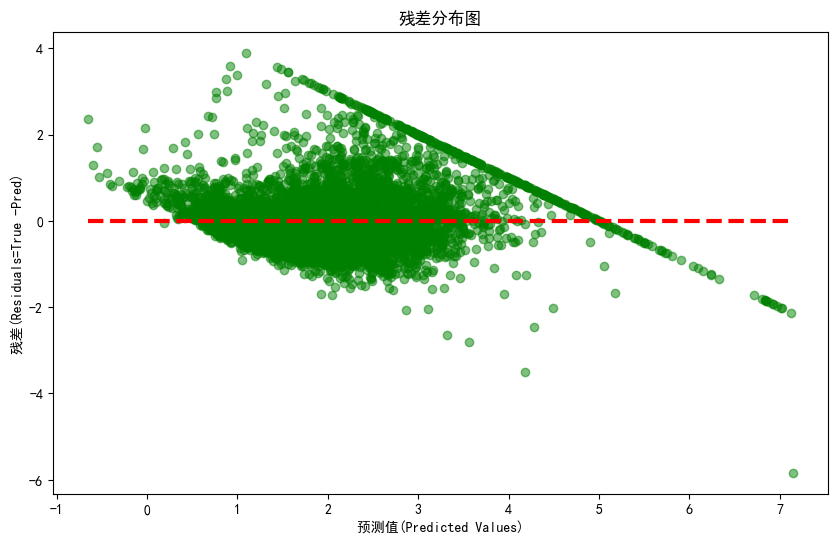

In [20]:
#

# 2.残差图(Redidual PLot)
#
# 残差=真实值 - 预测值
# 理想情况下,残差应该随机分布在0上下,形成一个没有明显规律的水平袋状图
residuals = Ytest - yhat

plt.figure(figsize=(10 ,6))
plt.scatter(yhat, residuals, alpha=0.5, color='green')
plt.hlines(y =0, xmin=yhat.min(), xmax=yhat.max(), colors='red', linestyles='--', lw=3)
plt.xlabel('预测值(Predicted Values)')
plt.ylabel('残差(Residuals=True -Pred)')
plt.title('残差分布图')
plt.show()  

================== 模型评估报告 ==================
1. 均方误差 (MSE): 0.5309
   (解释：预测值与真实值差值的平方和的均值，越小越好)
2. 平均绝对误差 (MAE): 0.5307
   (解释：预测值与真实值差值的绝对值的均值，越小越好)
3. 决定系数 (R^2): 0.6044
   (解释：拟合度达到了 60.44% 的数据方差，0.6左右说明模型拟合效果一般)
4. 模型自带 score (R^2): 0.6044


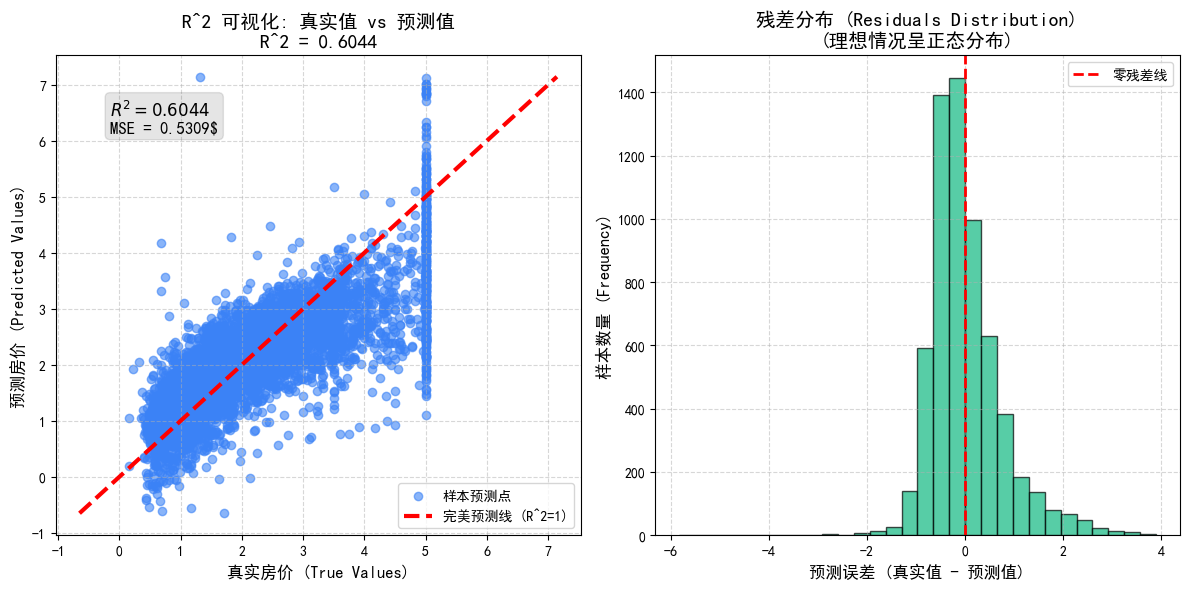

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. 打印文字报告
# ==========================================
print("================== 模型评估报告 ==================")
mse_val = mean_squared_error(Ytest, yhat)
mae_val = mean_absolute_error(Ytest, yhat)
r2_val = r2_score(Ytest, yhat)
model_score = reg.score(Xtest, Ytest)

print(f"1. 均方误差 (MSE): {mse_val:.4f}")
print(f"   (解释：预测值与真实值差值的平方和的均值，越小越好)")
print("=" * 30)

print(f"2. 平均绝对误差 (MAE): {mae_val:.4f}")
print(f"   (解释：预测值与真实值差值的绝对值的均值，越小越好)")
print("=" * 30)

print(f"3. 决定系数 (R^2): {r2_val:.4f}")
print(f"   (解释：拟合度达到了 {r2_val * 100:.2f}% 的数据方差，0.6左右说明模型拟合效果一般)")
print("=" * 30)

print(f"4. 模型自带 score (R^2): {model_score:.4f}")


# ==========================================
# 2. 增加 R^2 可视化图表
# ==========================================
plt.figure(figsize=(12, 6))

# -- 子图 1：真实值 vs 预测值 (直接体现 R^2)
plt.subplot(1, 2, 1)
plt.scatter(Ytest, yhat, color='#3B82f6', alpha=0.6, label='样本预测点')

# 绘制完美预测线 (y=x)
# 获取坐标轴范围
data_min = min(Ytest.min(), yhat.min())
data_max = max(Ytest.max(), yhat.max())
plt.plot([data_min, data_max], [data_min, data_max], 'r--', linewidth=3, label='完美预测线 (R^2=1)')

# 图表装饰
plt.title(f'R^2 可视化: 真实值 vs 预测值\nR^2 = {r2_val:.4f}', fontsize=14)
plt.xlabel('真实房价 (True Values)', fontsize=12)
plt.ylabel('预测房价 (Predicted Values)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 在图中添加文本框显示 R^2
plt.text(data_min + 0.5, data_max - 1, 
         f'$R^2 = {r2_val:.4f}$\nMSE = {mse_val:.4f}$',
         fontsize=12, bbox=dict(boxstyle='round', alpha=0.1, color='black'))

# -- 子图2：残差分布直方图 (辅助判断拟合质量) --
plt.subplot(1, 2, 2)
residuals = Ytest - yhat
plt.hist(residuals, bins=30, color='#10b981', edgecolor='black', alpha=0.7)

# 添加 0 参考线
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='零残差线')

# 图表装饰
plt.title('残差分布 (Residuals Distribution)\n(理想情况呈正态分布)', fontsize=14)
plt.xlabel('预测误差 (真实值 - 预测值)', fontsize=12)
plt.ylabel('样本数量 (Frequency)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

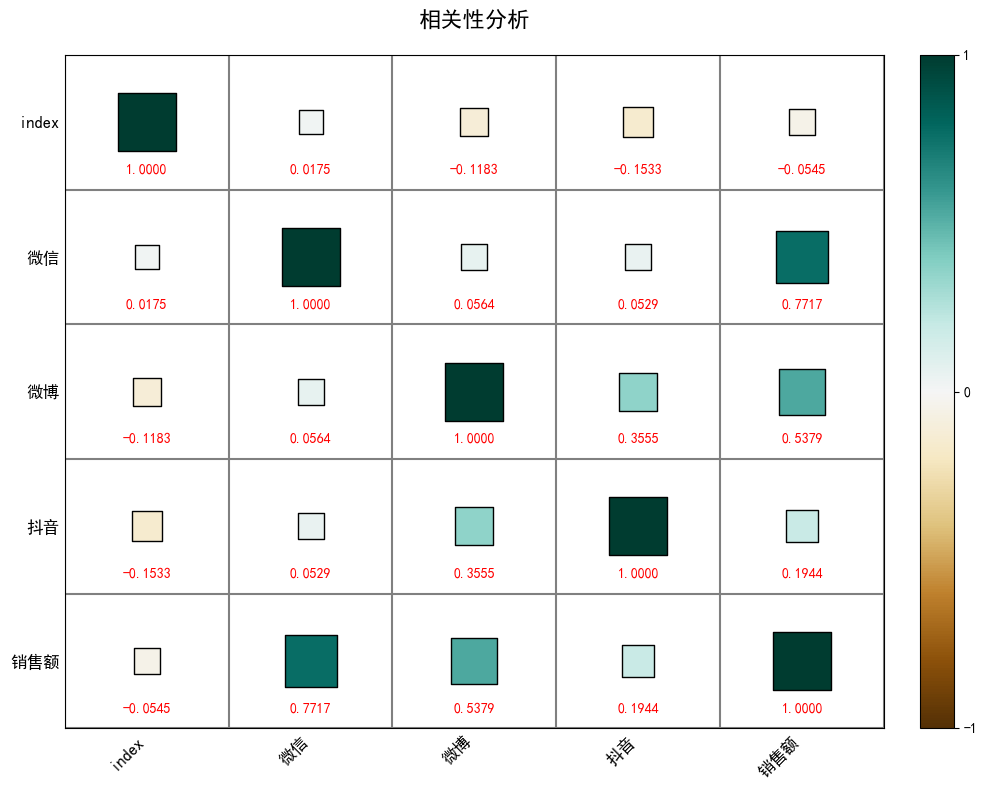

计算的相关性矩阵：
          index        微信        微博        抖音       销售额
index  1.000000  0.017513 -0.118314 -0.153252 -0.054530
微信     0.017513  1.000000  0.056387  0.052890  0.771718
微博    -0.118314  0.056387  1.000000  0.355500  0.537921
抖音    -0.153252  0.052890  0.355500  1.000000  0.194376
销售额   -0.054530  0.771718  0.537921  0.194376  1.000000


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ==========================================
# 1. 数据准备
# ==========================================

# 从csv读取文件 (这里假设你有一个 advertising.csv)
df_ads = pd.read_csv('./data/advertising.csv', encoding='utf-8')

# ==========================================
# 2. 计算相关系数矩阵
# ==========================================
corr_matrix = df_ads.corr()

# ==========================================
# 3. 自定义热力图绘制 (方块大小代表相关性)
# ==========================================

# 设置中文字体 (根据你的系统环境可能需要调整 SimHei, Microsoft YaHei 等)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def plot_custom_heatmap(corr, title="相关性分析"):
    # 获取列名和维度
    columns = corr.columns
    n = len(columns)
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 设置绘图范围
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    
    # 设置坐标轴标签
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(columns, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(columns[::-1], fontsize=12) # y轴标签逆序，使(0,0)在左上角符合矩阵直觉
    
    # 隐藏坐标轴刻度线
    ax.tick_params(axis='both', which='both', length=0)
    
    # 添加网格线 (作为方块的边框)
    ax.set_xticks(np.arange(n + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1.5)
    
    # 颜色映射 (这里使用棕色-绿色发散色系)
    # vmax=1, vmin=-1 确保0值对应中间的白色/浅色
    cmap = plt.get_cmap('BrBG') # 或 'RdBu_r'
    norm = Normalize(vmin=-1, vmax=1)
    
    # 遍历矩阵绘制方块
    # 注意: matplotlib的scatter默认原点在左下角，矩阵在左上角
    # row i 对应 y = n - 1 - i
    # col j 对应 x = j
    for i in range(n):
        for j in range(n):
            val = corr.iloc[i, j]
            
            # 1. 方块大小 (Size)
            # 大小(size) 跟绝对值成正比。绝对值越大，面积越大
            # 这里的 scaling_factor 用于调整方块的整体大小
            scaling_factor = 2500 
            size = (abs(val) * 0.6 + 0.1) * scaling_factor # 保证最小值也有一定大小
            
            # 2. 绘制方块 (Scatter)
            ax.scatter(j, n - 1 - i, s=size, c=[val], cmap=cmap, norm=norm, marker='s', edgecolors='black')
            
            # 3. 添加数值文本
            # 在方块下方显示具体数值，颜色设为红色以示区分
            ax.text(j, n - 1 - i - 0.35, f'{val:.4f}', 
                    ha='center', va='center', color='red', fontsize=10)
            
    # 添加颜色条 (Colorbar)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([-1, 0, 1]) # 简化颜色条刻度
    
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 执行绘图
# ==========================================
plot_custom_heatmap(corr_matrix)

# 5. 打印数值矩阵参考
print("计算的相关性矩阵：")
print(corr_matrix)

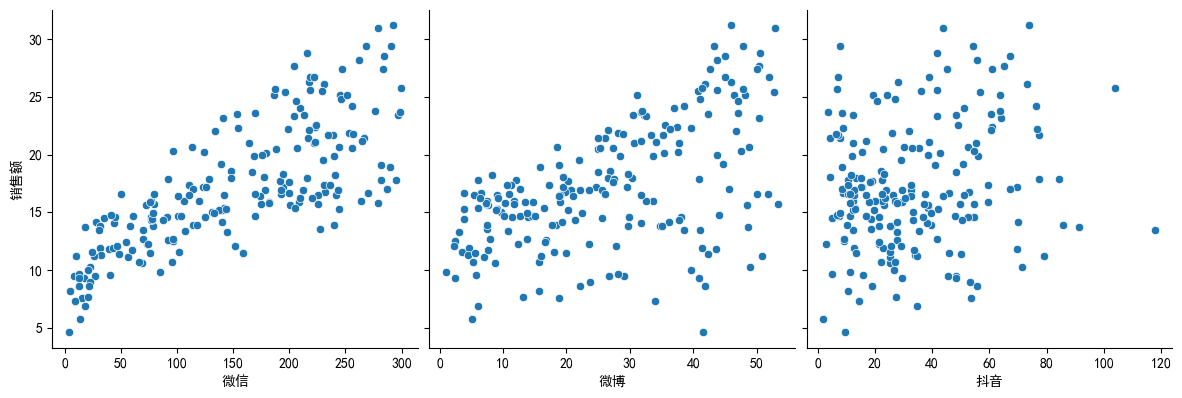

In [23]:
import seaborn as sns
sns.pairplot(df_ads,x_vars=['微信','微博','抖音'],y_vars='销售额',
height=4, aspect=1, kind='scatter')
plt.savefig("scatter1.png", dpi=300, bbox_inches='tight', pad_inches=0.0)